In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [220]:
fg_data = pd.read_csv("fear_greed_index.csv")
hist_data = pd.read_csv("historical_data.csv")

In [221]:
hist_data

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [222]:
fg_data

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


### Tasks According to Given PDF
**Part A** — Data preparation (must-have)
1. Load both datasets and document:
number of rows/columns
missing values / duplicates

2. Convert timestamps and align the datasets by date (daily level is fine).

3. Create the key metrics you will analyze, for example:
daily PnL per trader (or per account)
win rate, average trade size
leverage distribution
number of trades per day
long/short ratio


In [223]:
hist_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [224]:
fg_data.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [225]:
hist_data.duplicated().sum()

np.int64(0)

In [226]:
fg_data.duplicated().sum()

np.int64(0)

In [227]:
hist_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [228]:
fg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [229]:
hist_data['Timestamp'].duplicated().sum()

np.int64(211217)

In [230]:
hist_data['Timestamp'].nunique()

7

In [231]:
hist_data['datetime']  = pd.to_datetime(hist_data['Timestamp IST'],  format='%d-%m-%Y %H:%M', errors='coerce')
hist_data['date'] =  hist_data['datetime'].dt.date

In [232]:
hist_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

**Note:** there's also a numeric Timestamp column, but it only has 7 unique values across 211k rows, 

it won't give you correct daily alignment if you use it instead of Timestamp IST. 

The PDF doesn't say to drop it, so keep it in the dataframe, just don't use it as your alignment key.

In [233]:
hist_data

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25


In [234]:
fg_data['date'] = pd.to_datetime(fg_data['date']).dt.date
fg_data['date']

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, Length: 2644, dtype: object

In [235]:
fg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


### Merged the file

In [236]:
merge = hist_data.merge(fg_data, on = 'date', how = 'left')
merge

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed


In [237]:
merge.shape

(211224, 21)

In [238]:
merged = merge.rename(columns = {'datetime': 'Datetime',
                         'date': 'Date',
                         'value': 'Value',
                         'classification':'Classification',
                         'timestamp':'Timestamp'})

merged

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Datetime,Date,Timestamp,Value,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25 15:35:00,2025-04-25,1.745559e+09,60.0,Greed


### Create a Key Metrices

In [239]:
daily_PnL = merged.groupby(['Account','Date'])['Closed PnL'].sum()

In [240]:
daily_PnL.reset_index()

,Account,Date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [241]:
win_rate = merged['Closed PnL'].groupby(merged['Account']).mean()
win_rate.reset_index().head(10)

,Account,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-38.286626
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4.028119
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,161.133275
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,520.902331
9,0x430f09841d65beb3f27765503d0f850b8bce7713,336.735548


In [242]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean()
avg_trade_size.sort_values(ascending = False).reset_index().head(10)

,Account,Size USD
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,34396.580284
1,0xb899e522b5715391ae1d4f137653e7906c5e2115,22504.555829
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,17098.171055
3,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
4,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,9084.699093
5,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
6,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,8330.193371
7,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,7852.098338
8,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,7216.667245
9,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6279.002287


In [276]:
trade_per_day = merged.groupby('Date').size().sort_values(ascending = False)
print("====Number of Trade per Day====\n",trade_per_day)

====Number of Trade per Day====
 Date
2025-02-25    6246
2025-04-23    6159
2025-02-24    5616
2025-03-12    3968
2025-04-09    3967
              ... 
2024-09-08       1
2024-09-11       1
2024-10-04       1
2024-09-05       1
2024-08-29       1
Length: 480, dtype: int64


In [244]:
merged['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

### Part B — Analysis 

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
3. Identify 2–3 segments (examples):
   
   **.** high leverage vs low leverage traders
   
   **.** frequent vs infrequent traders
 
   **.** consistent winners vs inconsistent traders

   **.** Provide at least 3 insights backed by charts/tables.


In [245]:
merged['Classification'].value_counts()

Classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [246]:
merged['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [247]:
Closing_direction = ['Close Long', 'Close Short', 'Sell', 'Short > Long', 'Long > Short',
                      'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement']
closed = merged[merged['Direction'].isin(Closing_direction)].copy()

perf = closed.groupby('Classification').agg(
    total_PnL = ('Closed PnL',"sum"),
    mean_PnL = ('Closed PnL',"mean"),
    median_PnL = ('Closed PnL',"median"),
    win_rate = ('Closed PnL', lambda x: (x>0).mean()),
    trade_clount = ('Closed PnL',"size")
).round(3)
perf

# drawdown proxy: avg size of losing trades
avg_loss = closed[closed["Closed PnL"] < 0].groupby("Classification")["Closed PnL"].mean().round(2)
print(avg_loss)

Classification
Extreme Fear    -257.10
Extreme Greed   -119.92
Fear            -156.66
Greed           -181.97
Neutral         -121.73
Name: Closed PnL, dtype: float64


In [248]:
# trade frequency
daily_counts = merged.groupby(['Date','Classification']).size().reset_index(name = 'trades')
freq_sentiments = daily_counts.groupby("Classification")['trades'].agg(['mean','median']).round(1)
print("===Behavior Trade Frequency Sentiments===\n",freq_sentiments,"\n")

size_sentiments = merged.groupby("Classification")['Size USD'].mean().round(2)
print("===Behavior of Size Sentiments===\n", size_sentiments,"\n")

#long/short
long_dirs = ['Open Long', 'Close Long']
short_dirs = ['Open Short', 'Close Short']
ls = merged[merged['Direction'].isin(long_dirs + short_dirs)].copy()
ls["Bias"] = ls["Direction"].apply(lambda d: "Long" if d in long_dirs else "Short")
bias_table = ls.groupby("Classification")["Bias"].value_counts(normalize=True).unstack().round(3)
print("===Behavior of long/short bias Sentiments===\n", bias_table)




===Behavior Trade Frequency Sentiments===
                   mean  median
Classification                
Extreme Fear    1528.6  1097.5
Extreme Greed    350.8   133.0
Fear             679.5    88.0
Greed            260.6    47.0
Neutral          562.5    50.0 

===Behavior of Size Sentiments===
 Classification
Extreme Fear     5349.73
Extreme Greed    3112.25
Fear             7816.11
Greed            5736.88
Neutral          4782.73
Name: Size USD, dtype: float64 

===Behavior of long/short bias Sentiments===
 Bias             Long  Short
Classification              
Extreme Fear    0.678  0.322
Extreme Greed   0.488  0.512
Fear            0.636  0.364
Greed           0.418  0.582
Neutral         0.624  0.376


In [249]:
merged.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp',
 'Datetime',
 'Date',
 'Timestamp',
 'Value',
 'Classification']

In [272]:
# 3.Indentify segments
acct = merged.groupby("Account").agg(
    total_trades=("Closed PnL", "size"),
    avg_size_usd=("Size USD", "mean"),
).round(2)

closed_acct = closed.groupby("Account").agg(
    win_rate=("Closed PnL", lambda x: (x > 0).mean()),
    total_pnl=("Closed PnL", "sum"),
).round(3)

acct = acct.join(closed_acct)

# segment 1: position size 
med_size = acct["avg_size_usd"].median()
acct["size_segment"] = acct["avg_size_usd"].apply(lambda x: "High size" if x > med_size else "Low size")

# segment 2: trade frequency
med_freq = acct["total_trades"].median()
acct["freq_segment"] = acct["total_trades"].apply(lambda x: "Frequent" if x > med_freq else "Infrequent")

# segment 3: consistency
med_win = acct["win_rate"].median()
acct["consistency_segment"] = acct["win_rate"].apply(lambda x: "Consistent winner" if x > med_win else "Inconsistent")

print(acct.groupby("size_segment")["total_pnl"].agg(["mean", "count"]).round(1))
print(acct.groupby("freq_segment")["total_pnl"].agg(["mean", "count"]).round(1))
print(acct.groupby("consistency_segment")["total_pnl"].agg(["mean", "count"]).round(1))

                  mean  count
size_segment                 
High size     416806.0     16
Low size      226754.0     16
                  mean  count
freq_segment                 
Frequent      496527.7     16
Infrequent    147032.3     16
                         mean  count
consistency_segment                 
Consistent winner    281945.8     16
Inconsistent         361614.2     16


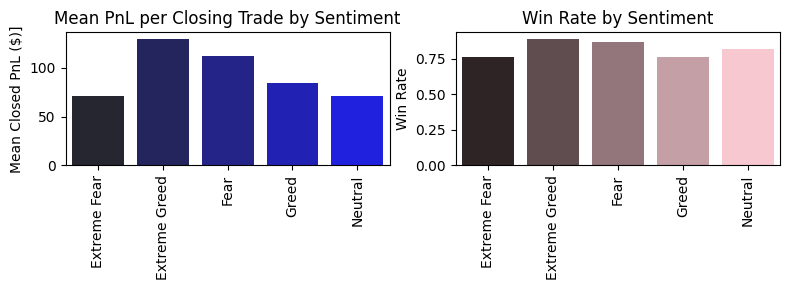

In [271]:
# Creating graphs
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.barplot(data=perf.reset_index(), x="Classification", y="mean_PnL", hue="Classification", legend=False, ax=axes[0], palette='dark:blue')
axes[0].set_title("Mean PnL per Closing Trade by Sentiment")
axes[0].set_ylabel("Mean Closed PnL ($)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(data=perf.reset_index(), x="Classification", y="win_rate", hue="Classification", legend=False, ax=axes[1], palette='dark:pink')
axes[1].set_title("Win Rate by Sentiment")
axes[1].set_ylabel("Win Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
#plt.savefig("Performance_by_sentiment.png", dpi=150)
plt.show()

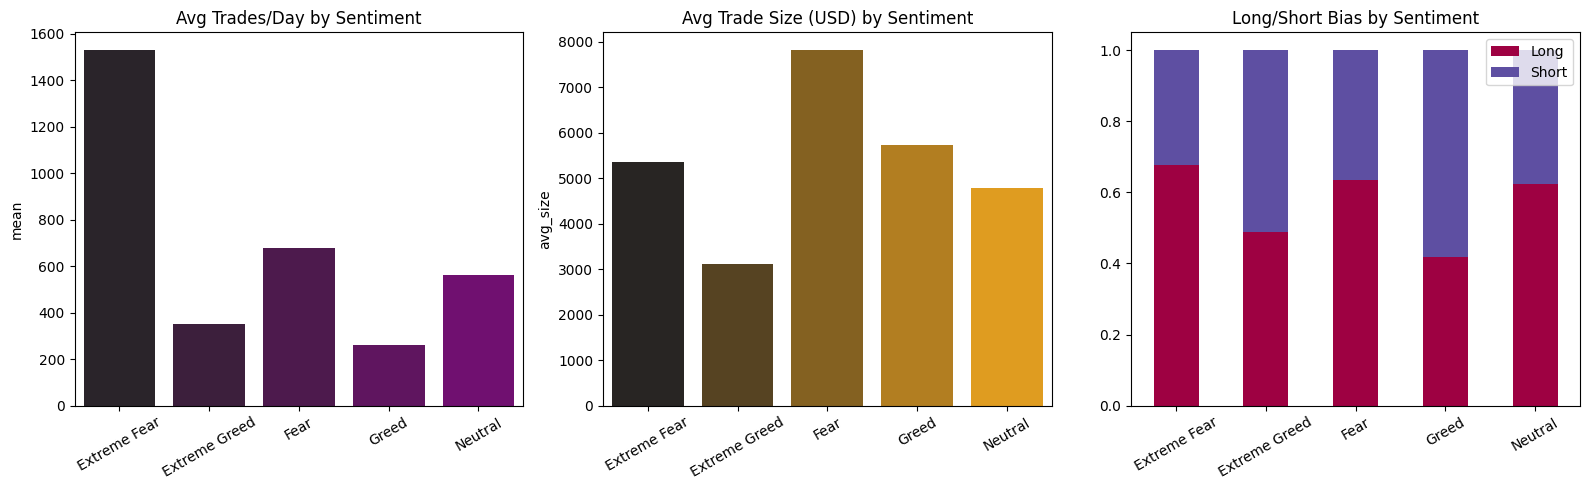

In [255]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=freq_sentiments.reset_index(), x="Classification", y="mean", hue="Classification", legend=False, ax=axes[0], palette = 'dark:purple')
axes[0].set_title("Avg Trades/Day by Sentiment")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=size_sentiments.reset_index(name="avg_size"), x="Classification", y="avg_size", hue="Classification", legend=False, ax=axes[1],palette = 'dark:orange')
axes[1].set_title("Avg Trade Size (USD) by Sentiment")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=30)

bias_table.plot(kind="bar", stacked=True, ax=axes[2], colormap="Spectral")
axes[2].set_title("Long/Short Bias by Sentiment")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title="")

plt.tight_layout()
#plt.savefig("Behavior_by_sentiment.png", dpi=150)
plt.show()

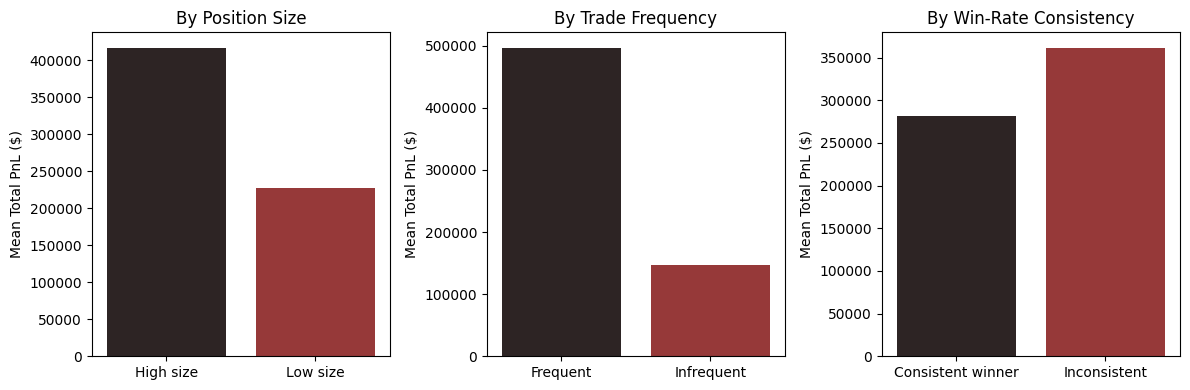

In [273]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, seg_col, title in zip(
    axes,
    ["size_segment", "freq_segment", "consistency_segment"],
    ["By Position Size", "By Trade Frequency", "By Win-Rate Consistency"],
):
    seg_pnl = acct.groupby(seg_col)["total_pnl"].mean()
    sns.barplot(x=seg_pnl.index, y=seg_pnl.values, hue=seg_pnl.index, legend=False, ax=ax, palette = 'dark:brown')
    ax.set_title(title)
    ax.set_ylabel("Mean Total PnL ($)")
    ax.set_xlabel("")

plt.tight_layout()
#plt.savefig("segments.png", dpi=150)
plt.show()

# Bonus

In [259]:
# ============================================================
# BONUS: Clustering traders into behavioral archetypes
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#  Build one row per account (size, frequency, win rate)
features = merged.groupby('Account').agg(
    avg_trade_size=('Size USD', 'mean'),
    total_trades=('Closed PnL', 'size'),
).round(2)

win_rate = closed.groupby('Account')['Closed PnL'].apply(lambda x: (x > 0).mean()).rename('win_rate')
features = features.join(win_rate).fillna(0)

print(features.head())

#  Scale the features (so no single column dominates)
X = StandardScaler().fit_transform(features)

# Run K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(X)

# See how many accounts landed in each cluster
print(features['cluster'].value_counts())

#  Profile each cluster (average feature values per group)
cluster_profile = features.groupby('cluster')[['avg_trade_size', 'total_trades', 'win_rate']].mean().round(2)
print(cluster_profile)

                                            avg_trade_size  total_trades  \
Account                                                                    
0x083384f897ee0f19899168e3b1bec365f52a9012        16159.58          3818   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         1653.23          7280   
0x271b280974205ca63b716753467d5a371de622ab         8893.00          3809   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4          507.63         13311   
0x2c229d22b100a7beb69122eed721cee9b24011dd         3138.89          3239   

                                            win_rate  
Account                                               
0x083384f897ee0f19899168e3b1bec365f52a9012  0.792725  
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.773644  
0x271b280974205ca63b716753467d5a371de622ab  0.715619  
0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.862079  
0x2c229d22b100a7beb69122eed721cee9b24011dd  0.817476  
cluster
0    15
2    13
1     4
Name: count, dtype: int64
         avg_trade_size 

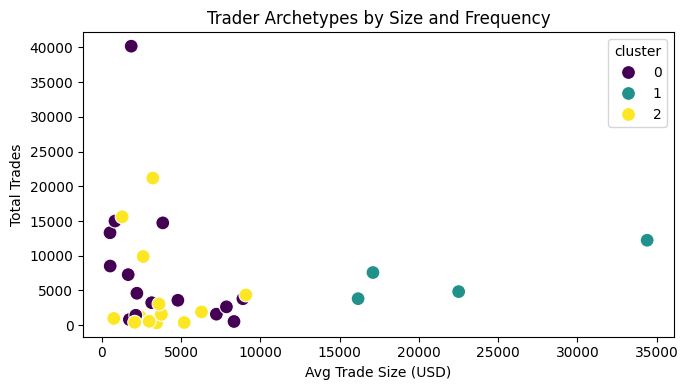

In [274]:
#Scatter Plot Graph
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=features, x='avg_trade_size', y='total_trades',
    hue='cluster', palette='viridis', s=100
)
plt.title('Trader Archetypes by Size and Frequency')
plt.xlabel('Avg Trade Size (USD)')
plt.ylabel('Total Trades')
plt.tight_layout()
plt.savefig('bonus_clusters.png', dpi=150)
plt.show()